# Text-to-Grasp 教程
## 输入 RGB + 深度 + 文本 → 输出抓取位姿 → 机械臂执行

参照 **YOLO_World-SAM-GraspNet**，将整个流程拆成可逐步运行、逐步可视化的 Jupyter Notebook。

### 流程概览
| Step | 内容 | 可视化 |
|------|------|--------|
| 1 | 连接 RoboCasa，采集 RGB + 深度图 | 📷 RGB 图 + 深度热力图 |
| 2 | YOLO-World 文本检测 + SAM 分割 | 🎯 检测框 + 分割 mask |
| 3 | 点云生成 + GraspNet 预测 | ☁️ 物体点云 + 候选抓取 |
| 4 | 后处理（碰撞/NMS/角度筛选） | 🏆 最佳抓取姿态 |
| 5 | 坐标系变换（相机 → 世界） | 📐 变换矩阵 |
| 6 | 机械臂执行抓取 | 🤖 自动抓取 |

> 每个 Step 都可以独立运行，运行后立刻看到可视化结果。


---
## Step 0: 导入依赖 & 配置参数

In [ ]:
import os, sys, time, logging
import numpy as np
import cv2
import torch
from client import RoboCasaClient
# import open3d as o3d
# from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
%matplotlib inline



DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"✅ 导入完成，设备: {DEVICE}")

✅ 导入完成，设备: cuda:0


---
## Step 1: 连接仿真环境 & 采集图像

连接 RoboCasa 仿真服务器，移动底盘进入工作区域，从腕部相机采集 RGB 和深度图。

In [40]:
# ---- 全局变量: 相机内参 (后续 cell 共用) ----
CAM_W, CAM_H = 256, 256

client = RoboCasaClient(host="localhost")
client.connect()

# ⚠️ 必须立即获取相机内参：后续推理期间 ZMQ buffer 会被图像数据挤满
print("等待相机内参...")
deadline = time.monotonic() + 8.0
while time.monotonic() < deadline:
    client.recv_state()
    cam_info = client.camera_info("eye_in_hand")  # ← 第一次赋值
    if cam_info.get("cam_pos") is not None and np.any(cam_info.get("cam_pos", [0,0,0])):
        print(f"  ✅ 已收到相机内参")
        break
    time.sleep(0.05)
else:
    print("  ⚠️ 未收到相机内参，后续坐标变换可能出错")

# 1.1 查看初始底盘位置
client.recv_state()
base0 = client.base_state["base_pos"]
print(f"底盘初始: x={base0[0]:.3f}, y={base0[1]:.3f}, yaw={base0[2]:.3f}")

# 1.2 移动底盘到工作区
print("移动中...")
for _ in range(10):
    client.send_base([0.0, 1.0, 0])
    time.sleep(0.1)
client.send_base([0.0, 0.0, 0.0])
time.sleep(0.3)

for i in range(10):
    client.send_base([-0.6, 0, 0])
    time.sleep(0.1)
client.send_base([0.0, 0.0, 0.0])

base1 = client.base_state["base_pos"]
print(f"移动后底盘: x={base1[0]:.3f}, y={base1[1]:.3f}, yaw={base1[2]:.3f}")

# 1.3 原子化采集: recv_state → rgb/depth/cam_info (同一帧)
client.recv_state()
rgb = client.camera_rgb("eye_in_hand")
depth_raw = client.camera_depth("eye_in_hand")
cam_info = client.camera_info("eye_in_hand")     # ← 第二次赋值 (覆盖)

cam_pos = np.array(cam_info["cam_pos"])
cam_quat = np.array(cam_info["cam_quat"])

# ---- 从服务端获取相机内参 ----
intrinsics = np.array(cam_info["intrinsics"])
FOCAL = intrinsics[0, 0]     # fx
CX    = intrinsics[0, 2]     # cx
CY    = intrinsics[1, 2]     # cy
print(f"相机内参 (from server): fx={FOCAL:.1f} fy={FOCAL:.1f} cx={CX:.0f} cy={CY:.0f}")
print(f"相机位置(world): {cam_pos}")
print(f"相机姿态(xyzw):   {cam_quat}")

# ---- 归一化深度检测 & 转换 ----
# 服务端更新后会在 camera_info 中发布 depth_near
if "depth_near" not in cam_info:
    print("⚠️ 服务端未更新，客户端转换归一化深度 → 米制...")
    near = 0.02
    far  = 100.0
    depth = near / (1.0 - depth_raw * (1.0 - near / far))
    print(f"  near={near:.4f}m, far={far:.1f}m")
else:
    depth = depth_raw
    print(f"✅ 服务端已做米制转换 (depth_near={cam_info['depth_near']:.4f})")

print(f"RGB: {rgb.shape}, dtype={rgb.dtype}")
print(f"Depth: {depth.shape}, dtype={depth.dtype}")
print(f"深度范围: [{depth.min():.3f}, {depth.max():.3f}] m")

# ====================================================================
# 🔍 相机坐标轴 & EEF 投影验证
# ====================================================================
from scipy.spatial.transform import Rotation as R

R_cv_to_mj = np.array([[1,0,0],[0,-1,0],[0,0,-1]])
R_mjcam_to_world = R.from_quat(cam_quat).as_matrix()
R_cvcam_to_world = R_mjcam_to_world @ R_cv_to_mj

cam_Z_world = R_cvcam_to_world[:, 2]
print(f"\n🔍 相机光轴前方 (world): [{cam_Z_world[0]:+.3f} {cam_Z_world[1]:+.3f} {cam_Z_world[2]:+.3f}]")
print(f"  💡 腕部俯视桌面: z 分量应 < 0 → {'✅' if cam_Z_world[2] < 0 else '❌'}")

# EEF 投影验证
s = client.arm_state
eef_world = np.array(s.get("eef_pos", [0,0,0]))
cam_eef_dist = np.linalg.norm(eef_world - cam_pos)

# world_to_camera
R_w2cv = R_cv_to_mj.T @ R_mjcam_to_world.T
eef_cam = R_w2cv @ (eef_world - cam_pos)

print(f"📐 相机→EEF 距离: {cam_eef_dist:.3f}m {'✅' if cam_eef_dist < 0.3 else '❌ >0.3m! 外参过期!'}")

if eef_cam[2] > 0.01:
    eef_u = FOCAL * eef_cam[0] / eef_cam[2] + CX
    eef_v = FOCAL * eef_cam[1] / eef_cam[2] + CY
    in_view = 0 <= eef_u < CAM_W and 0 <= eef_v < CAM_H
    print(f"EEF 投影像素: ({eef_u:.1f}, {eef_v:.1f}) {'✅' if in_view else '❌ 在图像外!'}")

等待相机内参...
  ✅ 已收到相机内参
底盘初始: x=9.221, y=11.776, yaw=-0.000
移动中...
移动后底盘: x=9.221, y=11.776, yaw=-0.000
相机内参 (from server): fx=166.8 fy=166.8 cx=128 cy=128
相机位置(world): [    0.68001     -2.2111       1.412]
相机姿态(xyzw):   [    0.10582     0.10584     0.74415     0.65103]
✅ 服务端已做米制转换 (depth_near=0.0197)
RGB: (256, 256, 3), dtype=uint8
Depth: (256, 256), dtype=float32
深度范围: [0.042, 1.393] m

🔍 相机光轴前方 (world): [-0.295 -0.020 -0.955]
  💡 腕部俯视桌面: z 分量应 < 0 → ✅
📐 相机→EEF 距离: 0.109m ✅
EEF 投影像素: (128.0, 214.0) ✅


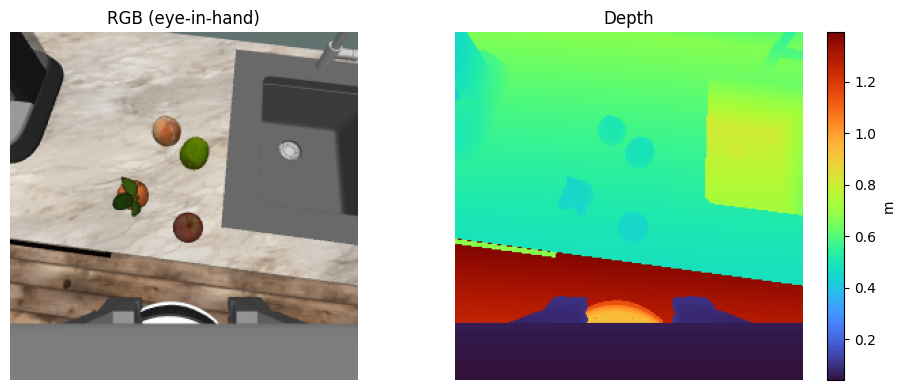

In [41]:
# 可视化 RGB + 深度图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.imshow(rgb)
ax.set_title("RGB (eye-in-hand)")
ax.axis("off")

ax = axes[1]
im = ax.imshow(depth, cmap="turbo")
ax.set_title("Depth")
ax.axis("off")
plt.colorbar(im, ax=ax, label="m")

plt.tight_layout()
plt.show()

---
## Step 2: YOLO-World 检测 + SAM 分割

**核心思路**：用户输入一段文本（如 "banana"），YOLO-World 在图中找到该物体 → 输出检测框 → SAM 用检测框作为 prompt 进行精细分割 → 得到物体 mask。

In [42]:
# 2.1 输入目标类别
text_prompt = input("请输入物体类别（如 banana, apple, cup）: ").strip()
print(f"目标: '{text_prompt}'")

目标: 'apple'


In [43]:
from ultralytics import YOLO
# from ultralytics.models.sam import Predictor as SAMPredictor
YOLO_MODEL = "yolov8x-world.pt"
# SAM_MODEL = "sam_b.pt"
# 2.2 YOLO-World 检测
yolo = YOLO(YOLO_MODEL)
yolo.set_classes([text_prompt])

# YOLO 内部用 BGR，先转换
rgb_bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
results = yolo.predict(rgb_bgr, verbose=False)

# 提取检测结果（置信度 > 0.25）
detections = []
for box in results[0].boxes:
    conf = box.conf.item()
    if conf > 0.25:
        detections.append({
            "xyxy": box.xyxy[0].tolist(),
            "conf": conf,
            "cls":  results[0].names[box.cls.item()],
        })

if not detections:
    print(f"❌ 未检测到 '{text_prompt}'")
else:
    best = max(detections, key=lambda d: d["conf"])
    print(f"✅ 检测到 '{best['cls']}'，置信度={best['conf']:.2f}，框={best['xyxy']}")

✅ 检测到 'apple'，置信度=0.77，框=[119.91096496582031, 132.9872283935547, 142.0635528564453, 155.27761840820312]


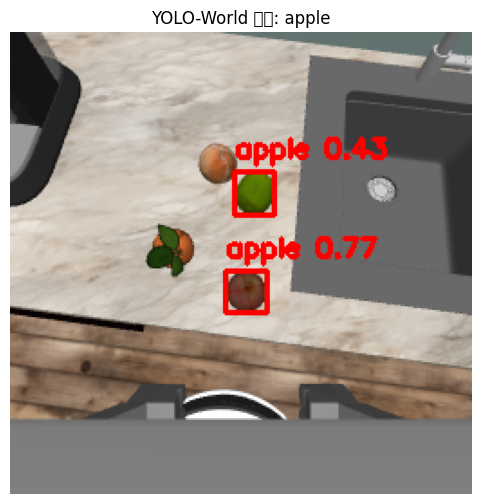

In [44]:
# 可视化检测框
vis = rgb.copy()
for d in detections:
    x1, y1, x2, y2 = map(int, d["xyxy"])
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(vis, f"{d['cls']} {d['conf']:.2f}", (x1, y1-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.title(f"YOLO-World 检测: {text_prompt}")
plt.axis("off")
plt.show()

In [45]:
from ultralytics.models.sam import Predictor as SAMPredictor
SAM_MODEL = "sam_b.pt"

# 2.3 SAM 分割
sam = SAMPredictor(overrides=dict(
    task="segment", mode="predict", model=SAM_MODEL, conf=0.25, save=False
))
sam.set_image(rgb)  # SAM 输入 RGB
sam_results = sam(bboxes=[best["xyxy"]])  # 用 YOLO 检测框引导

# 提取二值 mask
mask = sam_results[0].masks.data[0].cpu().numpy()
mask = (mask > 0).astype(np.uint8) * 255
print(f"Mask 尺寸: {mask.shape}，物体像素: {np.sum(mask > 0)}")

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)

0: 640x640 1 0, 9.8ms
Speed: 1.6ms preprocess, 9.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Mask 尺寸: (256, 256)，物体像素: 392


/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_205569/827698924.py:19: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


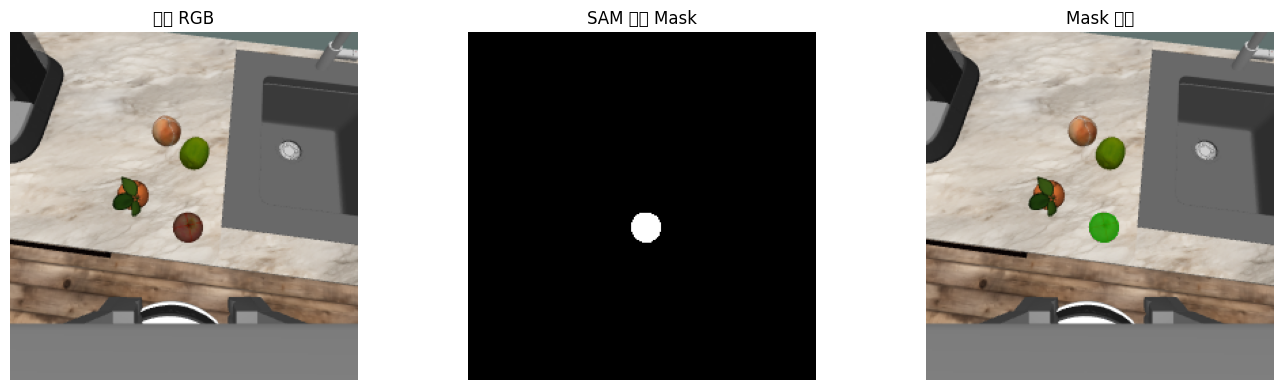

In [46]:
# 可视化：原图 + Mask + 叠加
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(rgb)
axes[0].set_title("原图 RGB")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("SAM 分割 Mask")
axes[1].axis("off")

# 叠加显示：绿色半透明 mask
overlay = rgb.copy()
overlay[mask > 0] = overlay[mask > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
axes[2].imshow(overlay)
axes[2].set_title("Mask 叠加")
axes[2].axis("off")

plt.tight_layout()
plt.show()

---
## Step 3: 点云生成 + GraspNet 预测

**核心思路**：深度图 + 相机内参 → 3D 点云 → 用 mask 提取物体区域 → 采样固定点数 → 送入 GraspNet → 输出候选抓取位姿。

In [47]:
from utils.data_utils import CameraInfo, create_point_cloud_from_depth_image

# 相机内参由 cell-4 (Step 1) 从服务端 camera_info 获取:
#   CAM_W, CAM_H, FOCAL, CX, CY  已在 cell-4 设为全局变量
DEPTH_SCALE = 1.0
DEPTH_MAX = 2.0

print(f"使用内参: fx={FOCAL:.1f} fy={FOCAL:.1f} cx={CX:.0f} cy={CY:.0f}")

# 3.1 深度图 → 点云
color_f = rgb.astype(np.float32) / 255.0
depth_f = depth.astype(np.float32)

camera = CameraInfo(CAM_W, CAM_H, FOCAL, FOCAL, CX, CY, DEPTH_SCALE)
cloud = create_point_cloud_from_depth_image(depth_f, camera, organized=True)

# 3.2 mask + 深度范围过滤
valid = (mask > 0) & (depth_f > 0) & (depth_f < DEPTH_MAX)
cloud_obj = cloud[valid]   # 物体点云 (N, 3)
color_obj = color_f[valid] # 物体颜色 (N, 3)
print(f"物体点数: {len(cloud_obj)}")

使用内参: fx=166.8 fy=166.8 cx=128 cy=128
物体点数: 392


In [48]:
import open3d as o3d

# 3.3 可视化物体点云（用 plotly 交互式）
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(cloud_obj.astype(np.float32))
pcd.colors = o3d.utility.Vector3dVector(color_obj.astype(np.float32))

# 下采样以便更快渲染
pcd_vis = pcd.uniform_down_sample(every_k_points=max(1, len(cloud_obj) // 3000))
print(f"可视化点数: {len(pcd_vis.points)}")
o3d.visualization.draw_plotly([pcd_vis])

可视化点数: 392


In [49]:
# ---------- 抓取参数 ----------
NUM_POINTS = 10000
COLLISION_THRESH = 0.01
VOXEL_SIZE = 0.01
VERTICAL_ANGLE_DEG = 30.0

GRASPNET_CKPT = os.path.join("logs", "log_rs", "checkpoint-rs.tar")

from models.graspnet import GraspNet, pred_decode
from graspnetAPI.graspnetAPI.grasp import GraspGroup

# 3.4 采样固定点数 → 加载 GraspNet → 前向推理
n = len(cloud_obj)
if n >= NUM_POINTS:
    idxs = np.random.choice(n, NUM_POINTS, replace=False)
else:
    idxs = np.concatenate([np.arange(n),
                           np.random.choice(n, NUM_POINTS - n, replace=True)])
cloud_sampled = cloud_obj[idxs]

# 加载模型
net = GraspNet(input_feature_dim=0, num_view=300, num_angle=12, num_depth=4,
               cylinder_radius=0.05, hmin=-0.01,
               hmax_list=[0.03, 0.04, 0.05], is_training=False)
net.to(DEVICE)
net.load_state_dict(torch.load(GRASPNET_CKPT, map_location=DEVICE)["model_state_dict"])
net.eval()
print("✅ GraspNet 加载完成")

# 推理
pts = torch.from_numpy(cloud_sampled[np.newaxis].astype(np.float32)).to(DEVICE)
with torch.no_grad():
    preds = pred_decode(net({"point_clouds": pts}))

gg = GraspGroup(preds[0].detach().cpu().numpy())
print(f"✅ 生成了 {len(gg)} 个候选抓取")

✅ GraspNet 加载完成
✅ 生成了 1024 个候选抓取


/tmp/ipykernel_205569/1428798411.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(GRASPNET_CKPT, map_location=DEVICE)["model_state_dict"])

In [50]:
# 3.5 可视化前 30 个候选抓取（未筛选）
preview = GraspGroup()
tmp = list(gg)
tmp.sort(key=lambda g: g.score, reverse=True)
for g in tmp[:30]:
    preview.add(g)

grippers = preview.to_open3d_geometry_list()
print(f"显示前 30 个候选抓取（共 {len(gg)} 个）")
o3d.visualization.draw_plotly([pcd_vis] + grippers)

显示前 30 个候选抓取（共 1024 个）


---
## Step 4: 后处理 —— 碰撞检测 → NMS → 垂直角度筛选

候选抓取很多，需要三步筛选：
1. **碰撞检测**：剔除夹爪会碰到场景的抓取
2. **NMS**：去除空间上重复的抓取
3. **垂直角度筛选**：只保留从上方接近的抓取（接近方向与竖直方向夹角 < 30°）

In [51]:
from collision_detector import ModelFreeCollisionDetector

# 4.1 碰撞检测 (物体点云)
if COLLISION_THRESH > 0:
    mfcd = ModelFreeCollisionDetector(np.asarray(cloud_obj), voxel_size=VOXEL_SIZE)
    gg = gg[~mfcd.detect(gg, approach_dist=0.05, collision_thresh=COLLISION_THRESH)]
    print(f"碰撞检测后: {len(gg)} 个")

# 4.2 NMS + 排序
gg = gg.nms()
gg.sort_by_score()
print(f"NMS 后: {len(gg)} 个")

# 4.3 PCA 物体长轴 (用于后续筛选)
obj_pts = np.asarray(cloud_obj)
obj_center = obj_pts.mean(axis=0)
X = obj_pts - obj_center
_, _, vh = np.linalg.svd(X, full_matrices=False)
obj_long_axis = vh[0] / (np.linalg.norm(vh[0]) + 1e-8)
print(f"物体中心: {obj_center}")
print(f"物体长轴: {obj_long_axis}")
print(f"\n待筛选抓取: {len(gg)} 个 → 下一步在 cell-21 中转到世界系后筛选")

碰撞检测后: 921 个
NMS 后: 17 个
物体中心: [  0.0067894    0.041407     0.45299]
物体长轴: [   -0.56743     -0.8213    0.059146]

待筛选抓取: 17 个 → 下一步在 cell-21 中转到世界系后筛选


In [52]:
# 4.4 可视化最佳抓取（红色）+ 前 5 个（蓝色）
preview = GraspGroup()
tmp = list(gg)
tmp.sort(key=lambda g: g.score, reverse=True)
for g in tmp[:30]:
    preview.add(g)
best_show = tmp[0]  # NMS 后最高分抓取 (相机系)

# ---- 尺度诊断 ----
pts = np.asarray(cloud_obj)
print(f"\n🔍 尺度诊断:")
print(f"  物体点数: {len(pts)}")
print(f"  点云 X 范围: [{pts[:,0].min():.4f}, {pts[:,0].max():.4f}] m, 尺寸: {pts[:,0].max()-pts[:,0].min():.4f} m")
print(f"  点云 Y 范围: [{pts[:,1].min():.4f}, {pts[:,1].max():.4f}] m, 尺寸: {pts[:,1].max()-pts[:,1].min():.4f} m")
print(f"  点云 Z 范围: [{pts[:,2].min():.4f}, {pts[:,2].max():.4f}] m, 尺寸: {pts[:,2].max()-pts[:,2].min():.4f} m")
print(f"  NMS 后候选: {len(gg)} 个")
print(f"  最高分抓取 (相机系): 得分={best_show.score:.4f}, 宽度={best_show.width:.4f}m")

grippers = preview.to_open3d_geometry_list()
print("\n🔴 红色 = 最佳  |  🔵 蓝色 = Top 2-30 (相机系，未筛选)")
o3d.visualization.draw_plotly([pcd_vis] + grippers)


🔍 尺度诊断:
  物体点数: 392
  点云 X 范围: [-0.0224, 0.0361] m, 尺寸: 0.0585 m
  点云 Y 范围: [0.0138, 0.0765] m, 尺寸: 0.0628 m
  点云 Z 范围: [0.4431, 0.4922] m, 尺寸: 0.0491 m
  NMS 后候选: 17 个
  最高分抓取 (相机系): 得分=0.9660, 宽度=0.0889m

🔴 红色 = 最佳  |  🔵 蓝色 = Top 2-30 (相机系，未筛选)


---
## Step 5: 坐标系变换（相机 → 世界）

GraspNet 输出的抓取位姿是在**相机坐标系**下的，控制机械臂需要**世界坐标系**。

$$T_{world}^{grasp} = T_{world}^{cam} \cdot T_{cam}^{grasp}$$

其中 $T_{world}^{cam}$ 从 `camera_info` 获取（相机在世界系下的外参）。

In [53]:
# 5.1 相机外参 (cell-4 已获取)
from scipy.spatial.transform import Rotation as R

print(f"相机位置 (world): {cam_pos}")
print(f"相机姿态 (xyzw):   {cam_quat}")

# 5.2 变换矩阵: 相机系 → 世界系
R_mjcam_to_world = R.from_quat(cam_quat).as_matrix()
R_cv_to_mj = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
R_cvcam_to_world = R_mjcam_to_world @ R_cv_to_mj

T_world_cam = np.eye(4)
T_world_cam[:3, :3] = R_cvcam_to_world
T_world_cam[:3, 3] = cam_pos

# 5.3 将所有抓取转到世界系
print(f"\n将 {len(gg)} 个抓取从相机系 → 世界系...")
grasps_world = []  # list of dict: {pos_w, rot_w_raw, score, width, depth, center_cam}
# GraspGroup 遍历 (gg[i] 方式)
for i in range(len(gg)):
    g = gg[i]
    T_cam_grasp = np.eye(4)
    T_cam_grasp[:3, :3] = g.rotation_matrix
    T_cam_grasp[:3, 3] = g.translation
    T_world_grasp = T_world_cam @ T_cam_grasp
    grasps_world.append({
        'pos_w': T_world_grasp[:3, 3],
        'rot_w_raw': T_world_grasp[:3, :3],  # GraspNet convention: col0=approach, col1=binormal, col2=opening
        'score': g.score,
        'width': g.width,
        'depth': g.depth,
        'center_cam': g.translation,
    })

# 5.4 在世界系中筛选: 垂直桌面(approach 沿 -Z) + 宽度 + 距离物体中心
# 世界系中桌面法向 = -Z (朝下)
table_down_world = np.array([0.0, 0.0, -1.0])

MIN_WIDTH = 0.015
MAX_WIDTH = 0.08
MAX_CENTER_DIST = 0.10
ANGLE_MAX_DEG = 35
angle_max = np.deg2rad(ANGLE_MAX_DEG)

# 将物体中心也转到世界系
obj_center_w = (T_world_cam @ np.append(obj_center, 1.0))[:3]

filtered_w = []
for gw in grasps_world:
    R = gw['rot_w_raw']
    approach_w = R[:, 0] / (np.linalg.norm(R[:, 0]) + 1e-8)
    
    # 1. 接近方向垂直桌面 (沿世界 -Z)
    cos_a = np.clip(np.dot(approach_w, table_down_world), -1.0, 1.0)
    angle = np.arccos(cos_a)
    if angle > angle_max:
        continue
    
    # 2. 宽度合理
    if not (MIN_WIDTH <= gw['width'] <= MAX_WIDTH):
        continue
    
    # 3. 抓取位置靠近物体
    if np.linalg.norm(gw['pos_w'] - obj_center_w) > MAX_CENTER_DIST:
        continue
    
    filtered_w.append(gw)

# 逐级放宽
if not filtered_w:
    print("⚠️ 无满足约束的抓取，放宽条件...")
    for gw in grasps_world:
        R = gw['rot_w_raw']
        approach_w = R[:, 0] / (np.linalg.norm(R[:, 0]) + 1e-8)
        if np.dot(approach_w, table_down_world) < 0.5:  # 至少朝下
            continue
        if not (0.01 <= gw['width'] <= 0.10):
            continue
        if np.linalg.norm(gw['pos_w'] - obj_center_w) > 0.15:
            continue
        filtered_w.append(gw)

if not filtered_w:
    print("⚠️ 所有筛选失败，使用全部")
    filtered_w = grasps_world

filtered_w.sort(key=lambda x: x['score'], reverse=True)
best = filtered_w[0]

print(f"\n✅ 筛选后: {len(filtered_w)} 个 (共 {len(grasps_world)} 个候选)")
print(f"最佳 - 得分: {best['score']:.4f}, 宽度: {best['width']:.4f}m")

# 5.5 轴重映射: GraspNet → PandaOmron TCP
# col0=approach, col1=binormal(finger), col2=opening
# PandaOmron: X=手指沿物体, Y=开合跨物体, Z=接近
MAP_ID = 2
R_raw = best['rot_w_raw']
if MAP_ID == 1:
    grasp_rot_w = np.column_stack([-R_raw[:,1], -R_raw[:,2],  R_raw[:,0]])
elif MAP_ID == 2:
    grasp_rot_w = np.column_stack([-R_raw[:,2], -R_raw[:,1],  R_raw[:,0]])
else:
    grasp_rot_w = np.column_stack([ R_raw[:,1], -R_raw[:,2], -R_raw[:,0]])

grasp_pos_w = best['pos_w']

approach_w = grasp_rot_w[:, 2] / np.linalg.norm(grasp_rot_w[:, 2])
print(f"抓取位置(世界): {grasp_pos_w}")
print(f"接近方向(世界): {approach_w}")
print(f"  接近 vs 桌面法向(-Z)夹角: {np.rad2deg(np.arccos(np.clip(np.dot(approach_w, table_down_world), -1.0, 1.0))):.1f}°")

# 5.6 EEF 投影验证
client.recv_state()
s = client.arm_state
eef_world = np.array(s.get('eef_pos', [0,0,0]))
print(f"\n📐 相机→EEF: {np.linalg.norm(eef_world - cam_pos):.3f}m")

相机位置 (world): [    0.68001     -2.2111       1.412]
相机姿态 (xyzw):   [    0.10582     0.10584     0.74415     0.65103]

将 17 个抓取从相机系 → 世界系...

✅ 筛选后: 3 个 (共 17 个候选)
最佳 - 得分: 0.3799, 宽度: 0.0628m
抓取位置(世界): [    0.59948     -2.1967     0.97032]
接近方向(世界): [   -0.12144     -0.5148    -0.84867]
  接近 vs 桌面法向(-Z)夹角: 31.9°

📐 相机→EEF: 0.113m


In [54]:
# 可视化筛选后的抓取 (世界系)
import open3d as o3d
from graspnetAPI.graspnetAPI.grasp import Grasp

# 物体点云 → 世界系
obj_pts_w = (T_world_cam @ np.column_stack([obj_pts, np.ones(len(obj_pts))]).T).T[:, :3]
pcd_w = o3d.geometry.PointCloud()
pcd_w.points = o3d.utility.Vector3dVector(obj_pts_w.astype(np.float32))
pcd_w.paint_uniform_color([0, 0.8, 0])

# 构建 GraspGroup (世界系)
show_gg = GraspGroup()
for gw in filtered_w[:15]:
    g = Grasp()
    g.rotation_matrix = gw['rot_w_raw']
    g.translation = gw['pos_w']
    g.score = gw['score']
    g.width = gw['width']
    g.depth = gw['depth']
    show_gg.add(g)

grippers_w = show_gg.to_open3d_geometry_list()
coord = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

print(f"筛选后 {len(filtered_w)} 个 | 显示前 {min(15, len(filtered_w))} 个 (世界系)")
print("绿色=物体点云 | 坐标轴: 红X 绿Y 蓝Z(上)")
o3d.visualization.draw_plotly([pcd_w, coord] + grippers_w)

筛选后 3 个 | 显示前 3 个 (世界系)
绿色=物体点云 | 坐标轴: 红X 绿Y 蓝Z(上)


---
## Step 6: 机械臂执行抓取

使用 **delta 末端位姿控制** 的闭环 P 控制器，逐步执行：

```
预抓取(后退8cm) → 打开夹爪 → 接近 → 闭合夹爪 → 抬起15cm → 侧移放置 → 释放
```

In [55]:
def gripper(target, dur=1.0, label=""):
    """开/闭合夹爪, 从当前位置线性 ramp 到 target"""
    steps = int(dur / STEP_TIME)
    if steps < 1:
        steps = 1
    client.recv_state()
    try:
        current = float(client.arm_state.get("gripper_cmd", 0.5))
    except (TypeError, ValueError):
        current = 0.5
    print(f"  [夹爪] {label}: {current:.2f} → {target:.2f} (dur={dur}s, steps={steps})")
    for i in range(1, steps + 1):
        cmd = current + (target - current) * i / steps
        client.send_gripper(cmd)
        client.recv_state()
        time.sleep(STEP_TIME)
    client.send_gripper(target)
    time.sleep(0.1)
    # 读取最终值确认
    client.recv_state()
    final = client.arm_state.get("gripper_cmd", -1)
    print(f"  [夹爪] 完成, 最终: {final}")

In [56]:
# ====================================================================
# 抓取执行 (自包含)
# ====================================================================
assert 'grasp_pos_w' in dir(), '请先运行 cell-21 (坐标变换)!'

from scipy.spatial.transform import Rotation as R

APPROACH_OFFSET = 0.08
LIFT_HEIGHT    = 0.15
STEP_TIME      = 0.08
POS_TOL        = 0.02
ORI_TOL        = 0.30
OSC_MAX        = 1.0

def _world_to_osc(v):
    v = np.asarray(v).copy(); v[0]*=-1; v[1]*=-1; return v
def _scale_vec(v, m):
    mag = np.linalg.norm(v); return v/mag*m if mag>m else v
def _get_eef():
    s = client.arm_state
    return np.array(s.get('eef_pos',[0,0,0])), R.from_quat(np.array(s.get('eef_quat',[1,0,0,0]))).as_matrix()
def _stop(): client.send_delta_ee_pose([0,0,0,0,0,0])
def _rot_axis_angle(R_mat):
    ang = np.arccos(np.clip((np.trace(R_mat)-1)/2, -1.0, 1.0))
    if ang < 1e-6: return np.zeros(3), 0.0
    if np.abs(np.pi-ang) < 0.05:
        R_plus_I = R_mat + np.eye(3)
        best = R_plus_I[:, np.argmax(np.linalg.norm(R_plus_I, axis=0))]
        return best/np.linalg.norm(best), ang
    axis = np.array([R_mat[2,1]-R_mat[1,2], R_mat[0,2]-R_mat[2,0], R_mat[1,0]-R_mat[0,1]])/(2*np.sin(ang))
    return axis, ang

def move_to(target_pos, target_rot, label='移动', max_steps=500):
    prev_pn, stuck = None, 0
    for step in range(max_steps):
        client.recv_state(); cp, cr = _get_eef()
        pe = target_pos - cp; pn = np.linalg.norm(pe)
        axis_w, ang = _rot_axis_angle(target_rot @ cr.T)
        if step==0:
            print(f'  [{label}] step0: pos_err={pn:.3f}m, ang={np.rad2deg(ang):.0f}°')
        if step%100==0 and step>0:
            print(f'  [{label}] step{step}: pos_err={pn:.3f}m, ang={np.rad2deg(ang):.0f}°')
        if pn < POS_TOL and ang < ORI_TOL:
            _stop()
            print(f'  [{label}] OK (step {step+1}, pos={pn:.4f}m, ang={np.rad2deg(ang):.1f}°)')
            return True
        improving = (prev_pn is None) or (pn < prev_pn - 1e-4) or (ang < getattr(move_to, '_prev_ang', 999) - 1e-3)
        move_to._prev_ang = ang
        if not improving:
            stuck += 1
            if stuck > 100: break
        else: stuck = 0
        prev_pn = pn
        client.send_delta_ee_pose(np.concatenate([
            _scale_vec(_world_to_osc(pe)*4.0, OSC_MAX),
            _scale_vec(_world_to_osc(axis_w)*ang*3.0, OSC_MAX)]))
        time.sleep(STEP_TIME)
    _stop(); client.recv_state()
    cp_f, _ = _get_eef()
    print(f'  [{label}] FAIL pos={np.linalg.norm(target_pos-cp_f):.3f}m')
    return False

def move_to_approach(target_pos, approach_dir, label='接近', max_steps=300):
    """只控位置 + 接近方向(eef Z)，手指方向(eef X/Y)自由"""
    approach_dir = approach_dir / np.linalg.norm(approach_dir)
    prev_pn, stuck = None, 0
    for step in range(max_steps):
        client.recv_state(); cp, cr = _get_eef()
        pe = target_pos - cp; pn = np.linalg.norm(pe)
        # 构建目标姿态: Z=接近方向, X/Y由当前姿态投影
        target_z = approach_dir
        # 保持当前 eef Y 尽可能不变，投影到垂直于 target_z 的平面
        current_y = cr[:, 1]
        target_x = np.cross(current_y, target_z)
        if np.linalg.norm(target_x) < 1e-6:
            target_x = np.cross(cr[:, 0], target_z)
        target_x = target_x / np.linalg.norm(target_x)
        target_y = np.cross(target_z, target_x)
        target_y = target_y / np.linalg.norm(target_y)
        target_rot = np.column_stack([target_x, target_y, target_z])
        
        axis_w, ang = _rot_axis_angle(target_rot @ cr.T)
        if step==0:
            print(f'  [{label}] step0: pos_err={pn:.3f}m, ang={np.rad2deg(ang):.0f}°')
        if step%100==0 and step>0:
            print(f'  [{label}] step{step}: pos_err={pn:.3f}m, ang={np.rad2deg(ang):.0f}°')
        if pn < POS_TOL and ang < ORI_TOL:
            _stop()
            print(f'  [{label}] OK (step {step+1}, pos={pn:.4f}m, ang={np.rad2deg(ang):.1f}°)')
            return True
        improving = (prev_pn is None) or (pn < prev_pn - 1e-4)
        if not improving:
            stuck += 1
            if stuck > 100: break
        else: stuck = 0
        prev_pn = pn
        client.send_delta_ee_pose(np.concatenate([
            _scale_vec(_world_to_osc(pe)*4.0, OSC_MAX),
            _scale_vec(_world_to_osc(axis_w)*ang*2.0, OSC_MAX)]))
        time.sleep(STEP_TIME)
    _stop()
    print(f'  [{label}] FAIL pos={pn:.3f}m')
    return False

# ---- 夹爪控制 (持续发送确保执行) ----
def gripper_open(dur=1.5):
    print(f'  [夹爪] 张开 (dur={dur}s)...')
    deadline = time.monotonic() + dur
    while time.monotonic() < deadline:
        client.send_gripper(-1.0)  # 负值 = 张开 (velocity mode)
        time.sleep(0.05)
    client.send_gripper(0.0)  # stop

def gripper_close(dur=1.5):
    print(f'  [夹爪] 闭合 (dur={dur}s)...')
    deadline = time.monotonic() + dur
    while time.monotonic() < deadline:
        client.send_gripper(1.0)   # 正值 = 闭合 (velocity mode)
        time.sleep(0.05)
    client.send_gripper(0.0)  # stop

# ---- 执行 ----
pre_grasp_pos = grasp_pos_w - APPROACH_OFFSET * grasp_rot_w[:, 2]
lift_pos       = grasp_pos_w + np.array([0, 0, LIFT_HEIGHT])
print(f'\n抓取目标: {grasp_pos_w}')
print(f'预抓取:   {pre_grasp_pos}')

print('\n--- 预抓取 (只控位置，不管姿态) ---')
client.recv_state(); _, cr = _get_eef()
# 预抓取: 只控位置到目标上方，保持当前姿态（避免 MAP 切换导致旋转卡死）
POS_TOL_SAVE = POS_TOL; POS_TOL = 0.01
ok = move_to(pre_grasp_pos, cr, '预抓取(仅位置)', max_steps=300)
POS_TOL = POS_TOL_SAVE
assert ok, '预抓取失败'

print('\n--- 打开夹爪 ---')
gripper_open(dur=1.5)

print('\n--- 接近 (姿态+位置) ---')
ok1 = move_to_approach(grasp_pos_w, grasp_rot_w[:, 2], '接近', max_steps=400)

# 姿态对齐后，沿末端 Z 轴 (接近方向) 向前推进 2cm
print('\n--- 最终贴紧 (沿末端方向 +2cm) ---')
client.recv_state(); cp_now, cr_now = _get_eef()
push_target = cp_now + 0.05 * cr_now[:, 2]  # 沿 eef Z 轴前进 2cm
POS_TOL_SAVE2 = POS_TOL; POS_TOL = 0.01
ok2 = move_to(push_target, cr_now, '最终贴紧', max_steps=150)
POS_TOL = POS_TOL_SAVE2
if not (ok1 or ok2): print('WARNING: 未完全贴紧')

print('\n--- 闭合 ---')
gripper_close(dur=1.5)

print('\n--- 抬起 ---')
client.recv_state(); _, cr = _get_eef()
move_to(lift_pos, cr, '抬起')

# ---- 放置: 垂直向下 → 右移 → 下降 → 松开 ----
print('\n--- 放置: 旋转垂直桌面向下 ---')
client.recv_state(); cp_now, _ = _get_eef()
# 目标姿态: eef Z 垂直朝下 (world -Z)
vert_z = np.array([0.0, 0.0, -1.0])
# eef X 取当前 X 投影到水平面
vert_x = np.cross(np.array([0.0, 1.0, 0.0]), vert_z)  # world X
vert_x = vert_x / np.linalg.norm(vert_x)
vert_y = np.cross(vert_z, vert_x)
vert_rot = np.column_stack([vert_x, vert_y, vert_z])
move_to(cp_now, vert_rot, '旋转垂直', max_steps=300)

print('\n--- 放置: 底盘右移 ---')
for _ in range(15):
    client.send_base([0.0, -0.85, 0])  # Y 方向移动
    time.sleep(0.1)
client.send_base([0.0, 0.0, 0.0])
time.sleep(0.3)

print('\n--- 放置: 下降 ---')
client.recv_state(); cp_now, cr_now = _get_eef()
lower_target = cp_now + np.array([-0.2, 0.0, -0.12])  # 下降 12cm
move_to(lower_target, cr_now, '下降', max_steps=200)

print('\n--- 放置: 松开 ---')
gripper_open(dur=1.5)

print('\n✅ 抓取+放置完成!')


抓取目标: [    0.59948     -2.1967     0.97032]
预抓取:   [    0.60919     -2.1555      1.0382]

--- 预抓取 (只控位置，不管姿态) ---
  [预抓取(仅位置)] step0: pos_err=0.288m, ang=0°
  [预抓取(仅位置)] OK (step 59, pos=0.0096m, ang=0.1°)

--- 打开夹爪 ---
  [夹爪] 张开 (dur=1.5s)...

--- 接近 (姿态+位置) ---
  [接近] step0: pos_err=0.087m, ang=31°
  [接近] OK (step 29, pos=0.0189m, ang=0.1°)

--- 最终贴紧 (沿末端方向 +2cm) ---
  [最终贴紧] step0: pos_err=0.050m, ang=0°
  [最终贴紧] step100: pos_err=0.013m, ang=0°
  [最终贴紧] FAIL pos=0.013m

--- 闭合 ---
  [夹爪] 闭合 (dur=1.5s)...

--- 抬起 ---
  [抬起] step0: pos_err=0.168m, ang=0°
  [抬起] OK (step 44, pos=0.0195m, ang=0.0°)

--- 放置: 旋转垂直桌面向下 ---
  [旋转垂直] step0: pos_err=0.000m, ang=109°
  [旋转垂直] OK (step 41, pos=0.0199m, ang=0.0°)

--- 放置: 底盘右移 ---

--- 放置: 下降 ---
  [下降] step0: pos_err=0.233m, ang=0°
  [下降] OK (step 46, pos=0.0200m, ang=0.0°)

--- 放置: 松开 ---
  [夹爪] 张开 (dur=1.5s)...

✅ 抓取+放置完成!


In [57]:
#client.reset(layout_id=11, style_id=14)